In [ ]:
import sys
import os

# Dynamically find the project root (OR_SUC) so it can be run from anywhere
current_dir = os.getcwd()
while current_dir != '/' and not (os.path.exists(os.path.join(current_dir, 'src')) and os.path.exists(os.path.join(current_dir, 'data'))):
    current_dir = os.path.dirname(current_dir)
if current_dir != '/':
    os.chdir(current_dir)
    sys.path.append(os.path.abspath('src'))


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import gurobi_logtools as glt

# Analyse the results all methods

In [3]:
theta_list = [1e-1]  # Wasserstein radius. Bonferroni approximation requires small theta for feasibility
epsilon_list = [0.4, 0.2]  # the risk level
gurobi_seed_list_allmethods = [i for i in range(0, 10000*30, 10000)] 
num_gen_list = [10]  # the number of thermal generators
N_WDR_list = [50]  # the number of scenarios for the WDRJCC
load_scaling_factor_list = [2]  # [1] the scaling factor for the load
T_list = [2]
network_name = 'case24_ieee_rts'
Fgap = 0.001
quadra_cost = True
bigM = 1e5
thread=4
timelimit = 3600

param_comb = list(itertools.product(load_scaling_factor_list, epsilon_list, theta_list, T_list, num_gen_list, N_WDR_list))
save_path_root = os.path.join(os.getcwd(), 'results', f'SUC_ALSO_results_bigM{int(bigM)}_thread{thread}')

# this is to compare other three linear approx schemes
def str_list(l):
    return f'[{", ".join([str(i) for i in l])}]'
def mynanmax(n):
    # if all nan, return nan; otherwise, return the nanmax
    return np.nan if all(np.isnan(i) for i in n) else np.nanmax(n)
def mynanmin(n):
    # if all nan, return nan; otherwise, return the nanmin
    return np.nan if all(np.isnan(i) for i in n) else np.nanmin(n)

def convert(n):
    # return the original number if it is not None nor nan, otherwise return nan
    if (n is None) or (np.isnan(n)):
        return np.nan
    else:
        return n

def n_nonan(n):
    # return the number of non-nan in the list
    return sum([1 for i in n if not np.isnan(i)])

def mynanmean(n):
    # if all nan, return nan; otherwise, return the nanmean
    return np.nan if all(np.isnan(i) for i in n) else np.nanmean(n)

def sortedmean(n, first_k):
    return mynanmean(np.sort(n)[:first_k])

## the process of the following function is quite similar to the previous "load_results" function, just extended to other three benchmarks
def load_all_results(param_comb, save_path_root):
    res_df = []
    res_all_df = []
    for param in param_comb:
        load_scaling_factor, epsilon, theta, T, num_gen, N_WDR = param
        min_cost_proposed_list = []
        reliability_proposed_list = []
        time_proposed_list = []

        min_cost_exact_list = []
        min_cost_exact_prop_diff_list = []
        reliability_exact_list = []
        time_exact_list = []
        
        min_cost_ori_list = []
        time_ori_list = []
        min_cost_wcvar_list = []
        time_wcvar_list = []
        min_cost_bonf_list = []
        time_bonf_list = []
        min_cost_sfla_also_list = []
        time_sfla_also_list = []
        
        min_cost_ori_prop_diff_list = []
        min_cost_wcvar_prop_diff_list = []
        min_cost_bonf_prop_diff_list = []
        min_cost_sfla_also_prop_diff_list = []
        
        proposed_status_list = []
        exact_status_list = []
        ori_status_list = []
        wcvar_status_list = []
        bonf_status_list = []
        sfla_also_status_list = []
        
        break_flag = False
        
        for gurobi_seed in gurobi_seed_list_allmethods:
            res_save_path_proposed = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_proposed_T{T}{"quadra_cost" if quadra_cost else ""}.npy')

            res_save_path_exact = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_exact_T{T}{"quadra_cost" if quadra_cost else ""}.npy')

            res_save_path_ori = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_ori_T{T}{"quadra_cost" if quadra_cost else ""}.npy')

            res_save_wcvar = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_wcvar_T{T}{"quadra_cost" if quadra_cost else ""}.npy')

            res_save_bonf = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_bonferroni_T{T}{"quadra_cost" if quadra_cost else ""}.npy')

            res_save_sfla_also = os.path.join(save_path_root, f'result_{network_name}_theta{theta}_epsilon{epsilon}_gurobi_seed{gurobi_seed}_num_gen{num_gen}_N_WDR{N_WDR}_load_scaling_factor{load_scaling_factor}_slfa_also_T{T}{"quadra_cost" if quadra_cost else ""}.npy')

            
            if not os.path.exists(res_save_path_proposed) or not os.path.exists(res_save_path_exact) or not os.path.exists(res_save_path_ori) or not os.path.exists(res_save_wcvar) or not os.path.exists(res_save_bonf) or not os.path.exists(res_save_sfla_also):
                break_flag = True
                break
            
            res_proposed = np.load(res_save_path_proposed, allow_pickle=True).item()
            res_exact = np.load(res_save_path_exact, allow_pickle=True).item()
            
            
            min_cost_proposed = res_proposed['min_cost (USD)']
            reliability_proposed = res_proposed['reliability_test (%)']
            time_proposed = res_proposed['t_solve (s)']
            
            min_cost_exact = res_exact['min_cost (USD)']
            reliability_exact = res_exact['reliability_test (%)']
            time_exact = res_exact['t_solve (s)']
            
            min_cost_ori = np.load(res_save_path_ori, allow_pickle=True).item()['min_cost (USD)']
            time_ori = np.load(res_save_path_ori, allow_pickle=True).item()['t_solve (s)']
            reliability_ori = np.load(res_save_path_ori, allow_pickle=True).item()['reliability_test (%)']
 
            
            min_cost_wcvar = np.load(res_save_wcvar, allow_pickle=True).item()['min_cost (USD)']
            time_wcvar = np.load(res_save_wcvar, allow_pickle=True).item()['t_solve (s)']
            reliability_wcvar = np.load(res_save_wcvar, allow_pickle=True).item()['reliability_test (%)']
            
            min_cost_bonf = np.load(res_save_bonf, allow_pickle=True).item()['min_cost (USD)']
            time_bonf = np.load(res_save_bonf, allow_pickle=True).item()['t_solve (s)']
            reliability_bonf = np.load(res_save_bonf, allow_pickle=True).item()['reliability_test (%)']

            min_cost_sfla_also = np.load(res_save_sfla_also, allow_pickle=True).item()['min_cost (USD)']
            time_sfla_also = np.load(res_save_sfla_also, allow_pickle=True).item()['t_solve (s)']
            reliability_sfla_also = np.load(res_save_sfla_also, allow_pickle=True).item()['reliability_test (%)']
            
            # append to list
            min_cost_proposed_list.append(convert(min_cost_proposed))
            reliability_proposed_list.append(convert(reliability_proposed))
            time_proposed_list.append(convert(time_proposed))
            
            min_cost_exact_list.append(convert(min_cost_exact))
            reliability_exact_list.append(convert(reliability_exact))
            time_exact_list.append(convert(time_exact))
            
            min_cost_exact_prop_diff_list.append(convert((min_cost_proposed - min_cost_exact)/min_cost_proposed))
            
            min_cost_ori_list.append(convert(min_cost_ori))
            time_ori_list.append(convert(time_ori))
            min_cost_wcvar_list.append(convert(min_cost_wcvar))
            time_wcvar_list.append(convert(time_wcvar))
            min_cost_bonf_list.append(convert(min_cost_bonf))
            time_bonf_list.append(convert(time_bonf))
            min_cost_sfla_also_list.append(convert(min_cost_sfla_also))
            time_sfla_also_list.append(convert(time_sfla_also))
            
            
            min_cost_ori_prop_diff_list.append(convert((min_cost_proposed - min_cost_ori)/min_cost_proposed))
            min_cost_wcvar_prop_diff_list.append(convert((min_cost_proposed - min_cost_wcvar)/min_cost_proposed))
            min_cost_bonf_prop_diff_list.append(convert((min_cost_proposed - min_cost_bonf)/min_cost_proposed))
            min_cost_sfla_also_prop_diff_list.append(convert((min_cost_proposed - min_cost_sfla_also)/min_cost_proposed))

            proposed_status = "OPTIMAL" if not np.isnan(min_cost_proposed) else "INFEASIBLE or NO SOLUTION"
            exact_status = "OPTIMAL" if not np.isnan(min_cost_exact) else "INFEASIBLE or NO SOLUTION"
            ori_status = "OPTIMAL" if not np.isnan(min_cost_ori) else "INFEASIBLE or NO SOLUTION"
            wcvar_status = "OPTIMAL" if not np.isnan(min_cost_wcvar) else "INFEASIBLE or NO SOLUTION"
            bonf_status = "OPTIMAL" if not np.isnan(min_cost_bonf) else "INFEASIBLE or NO SOLUTION"
            sfla_also_status = "OPTIMAL" if not np.isnan(min_cost_sfla_also) else "INFEASIBLE or NO SOLUTION"

            proposed_status_list.append(proposed_status)
            exact_status_list.append(exact_status)
            ori_status_list.append(ori_status)
            wcvar_status_list.append(wcvar_status)
            bonf_status_list.append(bonf_status)
            sfla_also_status_list.append(sfla_also_status)
            
            # append to df for each seed
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'SFLA',
                'Obj. Diff. (%)': 0,
                'time': time_proposed_list[-1],
                'Min Cost': min_cost_proposed_list[-1],
                'status': proposed_status,
            }, index=[0]))
            
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'ExactS',
                'time': time_exact_list[-1],
                'Obj. Diff. (%)': min_cost_exact_prop_diff_list[-1]*100,
                'Min Cost': min_cost_exact_list[-1],
                'status': exact_status,
            }, index=[0]))
            
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'LA',
                'time': time_ori_list[-1],
                'Obj. Diff. (%)': min_cost_ori_prop_diff_list[-1]*100,
                'Min Cost': min_cost_ori_list[-1],
                'status': ori_status,
            }, index=[0]))
            
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'W-CVaR',
                'time': time_wcvar_list[-1],
                'Obj. Diff. (%)': min_cost_wcvar_prop_diff_list[-1]*100,
                'Min Cost': min_cost_wcvar_list[-1],
                'status': wcvar_status,
            }, index=[0]))
            
            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'Bonferroni',
                'time': time_bonf_list[-1],
                'Obj. Diff. (%)': min_cost_bonf_prop_diff_list[-1]*100,
                'Min Cost': min_cost_bonf_list[-1],
                'status': bonf_status,
            }, index=[0]))

            res_all_df.append(pd.DataFrame({
                'eps': epsilon, 
                'theta': theta, 
                'num_gen': num_gen, 
                'N_WDR': N_WDR, 
                'method': 'ALSO-X#',
                'time': time_sfla_also_list[-1],
                'Obj. Diff. (%)': min_cost_sfla_also_prop_diff_list[-1]*100,
                'Min Cost': min_cost_sfla_also_list[-1],
                'status': sfla_also_status,
            }, index=[0]))
        
    res_all_df = pd.concat(res_all_df, ignore_index=True)
    return res_all_df

res_all_methods_all_df = load_all_results(param_comb, save_path_root)
res_all_methods_all_df

,eps,theta,num_gen,N_WDR,method,Obj. Diff. (%),time,Min Cost,status
0,0.4,0.1,10,50,SFLA,0.000000,0.293319,109255.501953,OPTIMAL
1,0.4,0.1,10,50,ExactS,1.022979,478.106624,108137.841489,OPTIMAL
2,0.4,0.1,10,50,LA,0.057364,2.938802,109192.828846,OPTIMAL
3,0.4,0.1,10,50,W-CVaR,-0.286758,3.534845,109568.800447,OPTIMAL
4,0.4,0.1,10,50,Bonferroni,-8.625225,0.033693,118679.034432,OPTIMAL
...,...,...,...,...,...,...,...,...,...
355,0.2,0.1,10,50,ExactS,1.022262,1.020615,121682.239844,OPTIMAL
356,0.2,0.1,10,50,LA,0.000000,0.688240,122938.998469,OPTIMAL
357,0.2,0.1,10,50,W-CVaR,-0.524959,0.971238,123584.377927,OPTIMAL
358,0.2,0.1,10,50,Bonferroni,NaN,NaN,NaN,INFEASIBLE or NO SOLUTION


In [4]:
# print all statuses of the methods
print(f'the unique statuses in proposed: {res_all_methods_all_df[res_all_methods_all_df["method"] == "SFLA"]["status"].unique()}')
print(f'the unique statuses in exact: {res_all_methods_all_df[res_all_methods_all_df["method"] == "ExactS"]["status"].unique()}')
print(f'the unique statuses in LA: {res_all_methods_all_df[res_all_methods_all_df["method"] == "LA"]["status"].unique()}')
print(f'the unique statuses in W-CVaR: {res_all_methods_all_df[res_all_methods_all_df["method"] == "W-CVaR"]["status"].unique()}')
print(f'the unique statuses in Bonferroni: {res_all_methods_all_df[res_all_methods_all_df["method"] == "Bonferroni"]["status"].unique()}')
print(f'the unique statuses in SFLA-ALSO: {res_all_methods_all_df[res_all_methods_all_df["method"] == "SFLA-ALSO"]["status"].unique()}')

the unique statuses in proposed: ['OPTIMAL' 'INFEASIBLE or NO SOLUTION']
the unique statuses in exact: ['OPTIMAL']
the unique statuses in LA: ['OPTIMAL' 'INFEASIBLE or NO SOLUTION']
the unique statuses in W-CVaR: ['OPTIMAL' 'INFEASIBLE or NO SOLUTION']
the unique statuses in Bonferroni: ['OPTIMAL' 'INFEASIBLE or NO SOLUTION']
the unique statuses in SFLA-ALSO: []


We see that the Bonferroni method is infeasible for all cases, so we do not include it in the following plots.

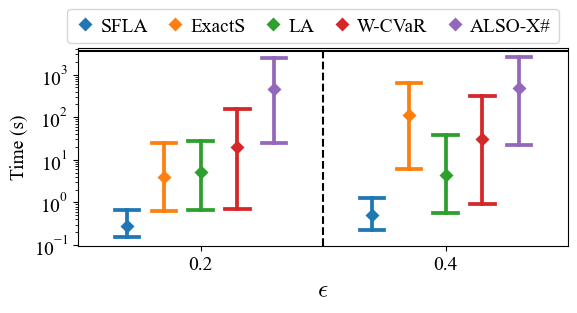

In [ ]:
# configure the plotting
import seaborn as sns
import matplotlib.pyplot as plt
# set plotting options, font size, and style to Academic theme (Times New Roman, etc.)
# Set matplotlib style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    "mathtext.fontset": "cm",
})

theta = theta_list[0]
T = T_list[0]
epsilon_list_plot = epsilon_list
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
# -----------------------------
res_all_methods_all_df_plot = res_all_methods_all_df[(res_all_methods_all_df['theta'] == theta)].copy()
# drop Bonferroni
res_all_methods_all_df_plot_NB = res_all_methods_all_df_plot[res_all_methods_all_df_plot['method'] != 'Bonferroni'].copy()
sns.pointplot(x='eps', y='time', data=res_all_methods_all_df_plot_NB, ax=ax, 
         hue='method', dodge=.6, estimator='mean', markers=['D', 'D', 'D', 'D', 'D'], linestyle='none', errorbar=('pi', 95), zorder=10, capsize = .1, markersize=5)

ax.set_xlabel(r'$\epsilon$', fontsize=18)
ax.set_ylabel('Time (s)')
# log y scale
ax.set_yscale('log')
# do not display the legend
ax.get_legend().remove()
    
for line_i in range(0, len(res_all_methods_all_df_plot_NB['eps'].unique())-1):
    ax.axvline(line_i+.5, color='black', linestyle='--')
    
# plot a horizontal line at the timelimit
ax.axhline(timelimit, color='black', linestyle='-')
    
# create my own legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.54, 1.02), ncol=5, columnspacing=0.9, handletextpad=0.3, handlelength=1.)
plt.suptitle('')
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
# save the figure
path_name = os.path.join(os.path.dirname(save_path_root), 'figure', f'suc_also_time_{network_name}_T{T}{"quadra_cost" if quadra_cost else ""}_allmethods_Fgap{Fgap}.pdf')
if not os.path.exists(os.path.dirname(path_name)):
    os.makedirs(os.path.dirname(path_name))
plt.savefig(path_name)

In [6]:
res_all_methods_all_df_plot_NB

,eps,theta,num_gen,N_WDR,method,Obj. Diff. (%),time,Min Cost,status
0,0.4,0.1,10,50,SFLA,0.000000,0.293319,109255.501953,OPTIMAL
1,0.4,0.1,10,50,ExactS,1.022979,478.106624,108137.841489,OPTIMAL
2,0.4,0.1,10,50,LA,0.057364,2.938802,109192.828846,OPTIMAL
3,0.4,0.1,10,50,W-CVaR,-0.286758,3.534845,109568.800447,OPTIMAL
5,0.4,0.1,10,50,ALSO-X#,0.078125,500.869380,109170.146092,OPTIMAL
...,...,...,...,...,...,...,...,...,...
354,0.2,0.1,10,50,SFLA,0.000000,0.166032,122938.998469,OPTIMAL
355,0.2,0.1,10,50,ExactS,1.022262,1.020615,121682.239844,OPTIMAL
356,0.2,0.1,10,50,LA,0.000000,0.688240,122938.998469,OPTIMAL
357,0.2,0.1,10,50,W-CVaR,-0.524959,0.971238,123584.377927,OPTIMAL


C:\Users\Zhou_Ming\AppData\Local\Temp\ipykernel_4940\2720111290.py:10: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  sns.stripplot(x='eps', y='Obj. Diff. (%)', data=res_all_methods_all_df_plot_NB, ax=ax, hue = 'method', dodge=True, marker='o', alpha = 0.7, palette=palette)


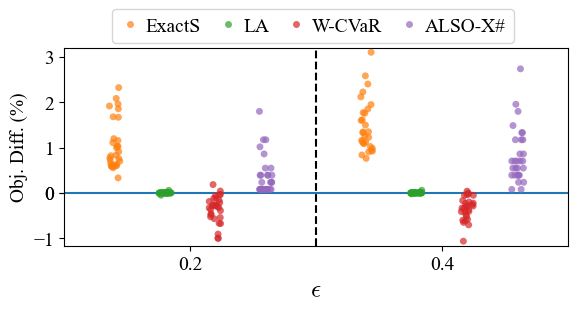

In [ ]:
epsilon_list_plot = epsilon_list
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
# -----------------------------
res_all_methods_all_df_plot = res_all_methods_all_df[(res_all_methods_all_df['theta'] == theta)].copy()
# drop Bonferroni
res_all_methods_all_df_plot_NB = res_all_methods_all_df_plot[res_all_methods_all_df_plot['method'].isin(['ExactS', 'LA', 'W-CVaR', 'ALSO-X#'])].copy()

# start from the second color of the color palette
palette = sns.color_palette('tab10', 10)[1:]
sns.stripplot(x='eps', y='Obj. Diff. (%)', data=res_all_methods_all_df_plot_NB, ax=ax, hue = 'method', dodge=True, marker='o', alpha = 0.7, palette=palette)

# Do not display the legend within the subplot
ax.get_legend().remove()
ax.set_ylabel('Obj. Diff. (%)')
ax.set_xlabel(r'$\epsilon$', fontsize=18)
# draw a horizontal line at 0
ax.axhline(0, color=sns.color_palette("tab10")[0], linestyle='-')
# yticks should at least include 0.1 and -0.1
yticks = ax.get_yticks()
yticks = np.concatenate([yticks, [0.0]])
# remove 0
# yticks = yticks[yticks != 0]
ax.set_yticks(yticks)
# remove xticks but keep the labels
# set ylim based on the max and min of the data
ax.set_ylim([np.nanmin(res_all_methods_all_df_plot_NB['Obj. Diff. (%)'])-0.1, np.nanmax(res_all_methods_all_df_plot_NB['Obj. Diff. (%)'])+0.1])
    
for line_i in range(0, len(res_all_methods_all_df_plot_NB['eps'].unique())-1):
    ax.axvline(line_i+.5, color='black', linestyle='--')
plt.suptitle('')
# create my own legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.54, 1.02), ncol=5, columnspacing=0.9, handletextpad=0.3, handlelength=1.)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
# save the figure
path_name = os.path.join(os.path.dirname(save_path_root), 'figure', f'suc_also_gap_{network_name}_T{T}{"quadra_cost" if quadra_cost else ""}_allmethods.pdf')
if not os.path.exists(os.path.dirname(path_name)):
    os.makedirs(os.path.dirname(path_name))
plt.savefig(path_name)